# Regression

## Import libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import seaborn as sns
import joblib
from pathlib import Path
from torch.utils.data import TensorDataset, DataLoader
from typing import List, Callable, Optional, Union, Tuple
from tqdm.auto import tqdm
import copy
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("gpu?:", torch.cuda.is_available())
print("cuda version:", torch.version.cuda)

OUTPUT_DIR = Path("deliverables")
threshold_path = OUTPUT_DIR / "threshold_model.joblib"

Using device: cuda
gpu?: True
cuda version: 13.0


## Loading dataset

In [3]:
# loading the California housing dataset
train_dataset = pd.read_csv("deliverables/train_data.csv")
test_dataset = pd.read_csv("deliverables/test_data.csv")
val_dataset = pd.read_csv("deliverables/validation_data.csv")

# Equalize positive and negative classes in the target column (Undersampling)
def balance_classes(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    pos_df = df[df[target_col] == 1]
    neg_df = df[df[target_col] == 0]
    min_len = min(len(pos_df), len(neg_df))
    return pd.concat([
        pos_df.sample(n=min_len, random_state=42),
        neg_df.sample(n=min_len, random_state=42)
    ]).sample(frac=1, random_state=42).reset_index(drop=True)

train_dataset = balance_classes(train_dataset, "target")
test_dataset = balance_classes(test_dataset, "target")
val_dataset = balance_classes(val_dataset, "target")

# Y_train = train_dataset["target"]
# X_train = train_dataset.drop(["target"], axis=1)

# Y_test = test_dataset["target"]
# X_test = test_dataset.drop(["target"], axis=1)

# Y_val = val_dataset["target"]
# X_val = val_dataset.drop(["target"], axis=1)

####

Y_train = train_dataset["target"]
X_train = train_dataset.drop(["target"], axis=1)
#X_train = train_dataset.drop(["target", "AnyHealthcare", "HvyAlcoholConsump", "Smoker", "Fruits", "Veggies", "Education", "NoDocbcCost", "Income", "Sex"], axis=1)
#X_train = train_dataset[["HighBP","BMI","GenHlth", "Age", "HighChol", "PhysActivity", "DiffWalk"]]

Y_test = test_dataset["target"]
X_test = test_dataset.drop(["target"], axis=1)
#X_test = test_dataset.drop(["target", "AnyHealthcare", "HvyAlcoholConsump", "Smoker", "Fruits", "Veggies", "Education", "NoDocbcCost", "Income", "Sex"], axis=1)
#X_test = test_dataset[["HighBP","BMI","GenHlth", "Age", "HighChol", "PhysActivity", "DiffWalk"]]

Y_val = val_dataset["target"]
X_val = val_dataset.drop(["target"], axis=1)
#X_val = val_dataset.drop(["target", "AnyHealthcare", "HvyAlcoholConsump", "Smoker", "Fruits", "Veggies", "Education", "NoDocbcCost", "Income", "Sex"], axis=1)
#X_val = val_dataset[["HighBP","BMI","GenHlth", "Age", "HighChol", "PhysActivity", "DiffWalk"]]

####


# Show Dataset Information
print(f"Training set: {X_train.shape[0]} samples. {X_train.shape[1]} features.")
print(f"Validation set: {X_val.shape[0]} samples.")
print(f"Features: {train_dataset.columns}")

# batch_size = 64

# X_train_t = torch.tensor(X_train.to_numpy(), dtype=torch.float32).to(device)
# Y_train_t = torch.tensor(Y_train.to_numpy(), dtype=torch.float32).view(-1, 1).to(device)

# X_val_t = torch.tensor(X_val.to_numpy(), dtype=torch.float32).to(device)
# Y_val_t = torch.tensor(Y_val.to_numpy(), dtype=torch.float32).view(-1, 1).to(device)

# train_dataset = TensorDataset(X_train_t, Y_train_t)
# val_dataset = TensorDataset(X_val_t, Y_val_t)

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=batch_size)

Training set: 49224 samples. 21 features.
Validation set: 10588 samples.
Features: Index(['BMI', 'Income', 'MentHlth', 'PhysHlth', 'Age', 'GenHlth', 'HighBP',
       'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
       'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump',
       'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'Education',
       'target'],
      dtype='str')


## MLP regression model

In [4]:
class PyTorchMLP(nn.Module):
    """
    Multi-Layer Perceptron using PyTorch with Keras-like API
    
    Features:
    - Parametric hidden layers
    - Customizable activation functions
    - Keras-style fit() and predict() methods
    - Automatic numpy/pandas to tensor conversion
    - Support for various loss functions and optimizers
    - Dropout, L2 Regularization, and Early Stopping
    """
    
    def __init__(self,
                 input_size: int,
                 hidden_layers: List[int],
                 output_size: int,
                 activation: Union[str, Callable] = 'relu',
                 output_activation: Union[str, Callable] = 'sigmoid',
                 loss_function: Union[str, Callable] = 'mse',
                 optimizer: str = 'adam',
                 learning_rate: float = 0.01,
                 epochs: int = 100,
                 batch_size: int = 32,
                 metrics: str = 'loss',
                 dropout: float = 0.0,
                 l2_reg: float = 0.0,
                 early_stopping: bool = False,
                 early_stopping_patience: int = None,
                 early_stopping_min_delta: float = None,
                 device: str = 'cpu'):
        """
        Initialize the MLP.
        
        Args:
            input_size: Number of input features
            hidden_layers: List of hidden layer sizes, e.g., [64, 32, 16]
            output_size: Number of output units
            activation: Activation function for hidden layers ('relu', 'tanh', 'sigmoid')
            output_activation: Activation for output layer ('sigmoid', 'softmax', 'linear')
            loss_function: Loss function ('mse', 'bce', 'cross_entropy')
            optimizer: Optimizer type ('adam', 'sgd', 'rmsprop')
            learning_rate: Learning rate for optimizer
            epochs: Number of training epochs (default: 100)
            batch_size: Batch size for training (default: 32)
            metric: Metric name to compute during training
            dropout: Dropout probability (0 to 1) applied after each hidden layer
            l2_reg: L2 regularization / weight decay term
            early_stopping: Whether to use early stopping based on validation loss
            early_stopping_patience: Number of epochs to wait for improvement before early stopping
            early_stopping_min_delta: Minimum change in validation loss to qualify as an improvement
            device: 'cpu' or 'cuda'
        """
        super(PyTorchMLP, self).__init__()
        
        self.input_size = input_size
        self.hidden_layers = hidden_layers
        self.output_size = output_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.metrics = metrics.lower()
        self.dropout = dropout
        self.l2_reg = l2_reg
        self.early_stopping = early_stopping
        self.early_stopping_patience = early_stopping_patience
        self.early_stopping_min_delta = early_stopping_min_delta
        self.device = torch.device(device)
        
        # Store activation functions
        self.activation_fn = self._get_activation(activation)
        self.output_activation_fn = self._get_activation(output_activation)
        self.output_activation_name = output_activation.__name__ if callable(output_activation) else output_activation
        
        # Build network
        layers = []
        layer_sizes = [input_size] + hidden_layers + [output_size]
        
        for i in range(len(layer_sizes) - 1):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            if i < len(layer_sizes) - 2:  # Don't add activation after output layer
                match activation:
                    case 'relu':
                        layers.append(nn.ReLU())
                    case 'leakyrelu':
                        layers.append(nn.LeakyReLU())
                    case 'tanh':
                        layers.append(nn.Tanh())
                    case 'sigmoid':
                        layers.append(nn.Sigmoid())
                    case _:
                        pass  # Default to no activation if unrecognized
                
                if self.dropout > 0:
                    layers.append(nn.Dropout(self.dropout))
        
        self.network = nn.Sequential(*layers)
        self.to(self.device)
        
        # Loss function
        self.loss_fn = self._get_loss_function(loss_function)
        
        # Optimizer
        self.optimizer = self._get_optimizer(optimizer)
        
    def _compute_metrics(self, y_pred: torch.Tensor, y_batch: torch.Tensor, metric_name: str) -> float:
        """Helper to compute evaluation metrics."""
        if metric_name == 'loss' or self.output_activation_name.lower() == 'linear':
            return self.loss_fn(y_pred, y_batch).item()
            
        with torch.no_grad():
            match self.output_activation_name.lower():
                case 'sigmoid':
                    preds = (y_pred >= 0.5).float()
                case 'tanh':
                    preds = (y_pred >= 0.5).float()
                case 'softmax':
                    preds = torch.argmax(y_pred, dim=1, keepdim=True).float()
                    if y_batch.dim() > 1 and y_batch.shape[1] > 1:
                        y_batch = torch.argmax(y_batch, dim=1, keepdim=True).float()
                case _:
                    return self.loss_fn(y_pred, y_batch).item()
                
            if metric_name == 'accuracy':
                return (preds == y_batch).float().mean().item()
            
            # True Positives, False Positives, False Negatives wrapper
            tp = ((preds == 1) & (y_batch == 1)).float().sum()
            fp = ((preds == 1) & (y_batch == 0)).float().sum()
            fn = ((preds == 0) & (y_batch == 1)).float().sum()
            
            match metric_name:
                case 'precision':
                    return (tp / (tp + fp + 1e-8)).item()
                case 'recall':
                    return (tp / (tp + fn + 1e-8)).item()
                case 'f1_score':
                    precision = tp / (tp + fp + 1e-8)
                    recall = tp / (tp + fn + 1e-8)
                    return (2 * precision * recall / (precision + recall + 1e-8)).item()
                
        return self.loss_fn(y_pred, y_batch).item()

    def _get_activation(self, activation: Union[str, Callable]) -> Callable:
        """Get activation function by name or return callable."""
        if callable(activation):
            return activation
        
        activations = {
            'relu': torch.relu,
            'leakyrelu': torch.nn.functional.leaky_relu,
            'tanh': torch.tanh,
            'sigmoid': torch.sigmoid,
            'softmax': lambda x: torch.softmax(x, dim=1),
            'linear': lambda x: x,
        }
        return activations.get(activation.lower(), torch.relu)
    
    def _get_loss_function(self, loss: Union[str, Callable]) -> Callable:
        """Get loss function by name or return callable."""
        if callable(loss):
            return loss
        
        loss_map = {
            'mse': nn.MSELoss(),
            'mae': nn.L1Loss(),
            'bce': nn.BCELoss(),
            'bce_logits': nn.BCEWithLogitsLoss(),
            'cross_entropy': nn.CrossEntropyLoss(),
        }
        return loss_map.get(loss.lower(), nn.MSELoss())
    
    def _get_optimizer(self, optimizer_name: str) -> optim.Optimizer:
        """Get optimizer."""
        optimizer_map = {
            'adam': optim.Adam,
            'sgd': optim.SGD,
            'rmsprop': optim.RMSprop,
            'adamw': optim.AdamW,
        }
        OptimizerClass = optimizer_map.get(optimizer_name.lower(), optim.Adam)
        return OptimizerClass(self.parameters(), lr=self.learning_rate, weight_decay=self.l2_reg)
    
    def _to_tensor(self, data: Union[np.ndarray, 'pd.DataFrame', torch.Tensor]) -> torch.Tensor:
        """Convert numpy array, pandas DataFrame, or list to tensor."""
        if isinstance(data, torch.Tensor):
            return data.to(self.device)
        elif hasattr(data, 'to_numpy'):  # pandas DataFrame
            return torch.FloatTensor(data.to_numpy().copy()).to(self.device)
        else:  # numpy array or list
            return torch.FloatTensor(np.asarray(data)).to(self.device)
    
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the network.
        
        Args:
            X: Input tensor of shape (batch_size, input_size)
            
        Returns:
            Output tensor with applied output activation
        """
        output = self.network(X)
        
        # Apply output activation
        if self.output_activation_name.lower() != 'linear':
            output = self.output_activation_fn(output)

        return output
    
    def backward(self, loss: torch.Tensor) -> None:
        """
        Backward pass (gradient computation and parameter update).
        
        Args:
            loss: Scalar loss value to backpropagate
        """
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
    
    def fit(self,
            X: Union[np.ndarray, 'pd.DataFrame'],
            y: Union[np.ndarray, 'pd.Series'],
            X_val: Optional[Union[np.ndarray, 'pd.DataFrame']] = None,
            y_val: Optional[Union[np.ndarray, 'pd.Series']] = None) -> dict:
        """
        Train the model on the data (Keras-style fit method).
        
        Args:
            X: Training input features (numpy, pandas, or tensor)
            y: Training target labels (numpy, pandas, or tensor)
            X_val: Optional validation input features for early stopping
            y_val: Optional validation target labels for early stopping
            
        Returns:
            Dictionary with training history
        """
        # Convert to tensors
        X_tensor = self._to_tensor(X)
        y_tensor = self._to_tensor(y)
        
        # Reshape y if needed
        if y_tensor.dim() == 1:
            y_tensor = y_tensor.unsqueeze(1)
        
        # Create data loader
        train_dataset = TensorDataset(X_tensor, y_tensor)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        
        # Training history
        history = {'loss': []}
        
        do_validation = self.early_stopping and X_val is not None and y_val is not None
        is_early_stopping_configured = self.early_stopping_min_delta is not None and self.early_stopping_patience is not None
        
        if do_validation and is_early_stopping_configured:
            history['val_loss'] = []
            if self.metrics != 'loss':
                history[f'val_{self.metrics}'] = []
                
            best_val_metric = float('inf') if self.metrics == 'loss' else float('-inf')
            best_weights = None
            epochs_no_improve = 0
            
            # Pre-compute validation loader ONCE to avoid massive overhead
            X_val_tensor = self._to_tensor(X_val)
            y_val_tensor = self._to_tensor(y_val)
            if y_val_tensor.dim() == 1:
                y_val_tensor = y_val_tensor.unsqueeze(1)
            val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
            val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)
        
        if self.early_stopping and not do_validation:
            print("Warning: Early stopping enabled but no validation data provided. Early stopping will be disabled.")
        
        if self.early_stopping and not is_early_stopping_configured:
            print("Warning: Early stopping enabled but patience or min_delta not configured. Early stopping will be disabled.")

        if tqdm is not None:
            pbar = tqdm(total=self.epochs, desc='Training')
        else:
            pbar = None

        # Training loop
        for epoch in range(self.epochs):
            self.train()
            epoch_loss = 0.0
            num_batches = 0
            
            for X_batch, y_batch in train_loader:
                # Forward pass
                y_pred = self.forward(X_batch)
                
                # Compute loss
                loss = self.loss_fn(y_pred, y_batch)
                
                # Backward pass
                self.backward(loss)
                
                epoch_loss += loss.item()
                num_batches += 1
            
            avg_loss = epoch_loss / num_batches
            history['loss'].append(avg_loss)
            
            # Validation and early stopping
            if do_validation and is_early_stopping_configured:
                # Fast evaluation using the pre-created val_loader
                self.eval()
                val_loss_sum = 0.0
                val_metric_sum = 0.0
                val_batches = 0
                with torch.no_grad():
                    for X_v, y_v in val_loader:
                        v_pred = self.forward(X_v)
                        v_loss = self.loss_fn(v_pred, y_v)
                        val_loss_sum += v_loss.item()
                        val_metric_sum += self._compute_metrics(v_pred, y_v, self.metrics)
                        val_batches += 1
                val_loss = val_loss_sum / val_batches
                val_metric_avg = val_metric_sum / val_batches
                
                history['val_loss'].append(val_loss)
                if self.metrics != 'loss':
                    history[f'val_{self.metrics}'].append(val_metric_avg)
                
                # Check early stopping condition based on metric
                if self.metrics == 'loss':
                    is_better = val_metric_avg < best_val_metric - self.early_stopping_min_delta
                else:
                    is_better = val_metric_avg > best_val_metric + self.early_stopping_min_delta
                
                if is_better:
                    best_val_metric = val_metric_avg
                    best_weights = copy.deepcopy(self.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    
                if epochs_no_improve >= self.early_stopping_patience:
                    if pbar is not None:
                        pbar.set_description('Stopped Early')
                        pbar.update((epoch + 1) - pbar.n)
                    print(f"Early stopping triggered at epoch {epoch+1}")
                    self.load_state_dict(best_weights)
                    break
            
            if pbar is not None:
                postfix = {'loss': f"{avg_loss:.4f}"}
                if do_validation and is_early_stopping_configured:
                    postfix['val_loss'] = f"{val_loss:.4f}"
                    if self.metrics != 'loss':
                        postfix[f'val_{self.metrics}'] = f"{val_metric_avg:.4f}"
                pbar.set_postfix(postfix)
                pbar.update(1)
        
        if pbar is not None:
            pbar.close()
            
        # Restore best weights if we didn't early stop but generated weights
        if do_validation and is_early_stopping_configured and best_weights is not None and epochs_no_improve < self.early_stopping_patience:
            self.load_state_dict(best_weights)

        return history
    
    def predict(self, X: Union[np.ndarray, 'pd.DataFrame']) -> np.ndarray:
        """
        Make predictions on new data (Keras-style predict method).
        
        Args:
            X: Input features (numpy, pandas, or tensor)
            
        Returns:
            Predictions as numpy array
        """
        # Convert to tensor
        X_tensor = self._to_tensor(X)
        
        # Create data loader
        dataset = TensorDataset(X_tensor)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)
        
        # Make predictions
        self.eval()
        predictions = []
        
        with torch.no_grad():
            for X_batch, in loader:
                y_pred = self.forward(X_batch)
                predictions.append(y_pred.cpu().numpy())
        
        # Concatenate all predictions
        predictions = np.vstack(predictions)
        
        return predictions
    
    def evaluate(self,
                 X: Union[np.ndarray, 'pd.DataFrame'],
                 y: Union[np.ndarray, 'pd.Series']) -> float:
        """
        Evaluate model on test data.
        
        Args:
            X: Test input features
            y: Test target labels
            
        Returns:
            Average loss on test data
        """
        X_tensor = self._to_tensor(X)
        y_tensor = self._to_tensor(y)
        
        if y_tensor.dim() == 1:
            y_tensor = y_tensor.unsqueeze(1)
        
        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)
        
        self.eval()
        total_loss = 0.0
        num_batches = 0
        
        with torch.no_grad():
            for X_batch, y_batch in loader:
                y_pred = self.forward(X_batch)
                loss = self.loss_fn(y_pred, y_batch)
                total_loss += loss.item()
                num_batches += 1
        
        return total_loss / num_batches


In [5]:
# # Create and train model
# model = PyTorchMLP(
#     input_size=len(X_train.columns),
#     hidden_layers=[16,]*2,
#     output_size=1,
#     activation="tanh",
#     output_activation="sigmoid",
#     loss_function='bce',
#     optimizer='adam',
#     learning_rate=0.003,
#     epochs=200,
#     batch_size=8192,
#     metrics='f1_score',
#     dropout=0.35,
#     l2_reg=0.001,
#     early_stopping=True,
#     early_stopping_patience=40,
#     early_stopping_min_delta=0,
#     device='cuda' if torch.cuda.is_available() else 'cpu'
# )

# print("Training model...")
# history = model.fit(
#     X_train, y_train, X_val, y_val
# )

# print("\nEvaluating on test data...")
# test_loss = model.evaluate(X_test, y_test)
# print(f"Test Loss: {test_loss:.4f}")

# print("\nMaking predictions...")
# predictions = model.predict(X_test)
# print(f"Predictions shape: {predictions.shape}")
# print(f"First 5 predictions: {predictions[:5].flatten()}")

In [6]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import copy

print("=== Setting up Cross Validation ===")

# Create StratifiedKFold object
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Combine train and validation data for cross validation
X_cv = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_cv = pd.concat([Y_train, Y_val], axis=0).reset_index(drop=True)

cv_accuracies = []
cv_f1_scores = []

best_cv_model = None
best_cv_f1 = -1
best_fold = -1

fold = 1

for train_idx, val_idx in skf.split(X_cv, y_cv):
    print(f"\n--- Training Fold {fold}/{n_splits} ---")
    
    # Split data for the current fold
    X_train_fold, X_val_fold = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
    y_train_fold, y_val_fold = y_cv.iloc[train_idx], y_cv.iloc[val_idx]
    
    # Initialize a fresh model
    cv_model = PyTorchMLP(
        input_size=len(X_cv.columns),
        hidden_layers=[64,]*5,
        output_size=1,
        activation="tanh",
        output_activation="sigmoid",
        loss_function='bce',
        optimizer='adam',
        learning_rate=0.001,
        epochs=100,
        batch_size=8192,
        metrics='f1_score',
        dropout=0.3,
        l2_reg=0.001,
        early_stopping=True,
        early_stopping_patience=10,
        early_stopping_min_delta=0,
        device='cuda' if torch.cuda.is_available() else 'cpu'
    )
    
    # Fit on fold data
    cv_model.fit(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    
    # Predict and evaluate on validation fold
    y_pred_proba = cv_model.predict(X_val_fold)
    y_pred_fold = (y_pred_proba > 0.5).astype(int)
    
    acc = accuracy_score(y_val_fold, y_pred_fold)
    f1 = f1_score(y_val_fold, y_pred_fold)
    
    print(f"Fold {fold} Results - Accuracy: {acc:.4f}, F1-Score: {f1:.4f}")
    
    cv_accuracies.append(acc)
    cv_f1_scores.append(f1)
    
    # Memorize the best model based on F1-Score
    if f1 > best_cv_f1:
        best_cv_f1 = f1
        best_cv_model = copy.deepcopy(cv_model)
        best_fold = fold
        
    fold += 1

print("\n=== Cross Validation Results ===")
print(f"Mean Accuracy: {np.mean(cv_accuracies):.4f} +/- {np.std(cv_accuracies):.4f}")
print(f"Mean F1-Score: {np.mean(cv_f1_scores):.4f} +/- {np.std(cv_f1_scores):.4f}")
print(f"Best Model found in Fold {best_fold} with F1-Score: {best_cv_f1:.4f}")

=== Setting up Cross Validation ===

--- Training Fold 1/5 ---


Stopped Early:  39%|███▉      | 39/100 [00:32<00:50,  1.21it/s, loss=0.5413, val_loss=0.5272, val_f1_score=0.7443]


Early stopping triggered at epoch 39
Fold 1 Results - Accuracy: 0.7348, F1-Score: 0.7523

--- Training Fold 2/5 ---


Stopped Early:  51%|█████     | 51/100 [00:43<00:41,  1.17it/s, loss=0.5409, val_loss=0.5257, val_f1_score=0.7435]


Early stopping triggered at epoch 51
Fold 2 Results - Accuracy: 0.7415, F1-Score: 0.7570

--- Training Fold 3/5 ---


...

Early stopping triggered at epoch 33
Fold 3 Results - Accuracy: 0.7299, F1-Score: 0.7482

--- Training Fold 4/5 ---


Stopped Early:  32%|███▏      | 32/100 [00:25<00:55,  1.24it/s, loss=0.5421, val_loss=0.5451, val_f1_score=0.7344]


Early stopping triggered at epoch 32
Fold 4 Results - Accuracy: 0.7225, F1-Score: 0.7373

--- Training Fold 5/5 ---


Stopped Early:  60%|██████    | 60/100 [00:48<00:32,  1.24it/s, loss=0.5384, val_loss=0.5343, val_f1_score=0.7427]

Early stopping triggered at epoch 60
Fold 5 Results - Accuracy: 0.7314, F1-Score: 0.7495

=== Cross Validation Results ===
Mean Accuracy: 0.7320 +/- 0.0062
Mean F1-Score: 0.7489 +/- 0.0065
Best Model found in Fold 2 with F1-Score: 0.7570


In [7]:
model = best_cv_model


=== THRESHOLD ANALYSIS ===

=== OPTIMAL THRESHOLD ===
Best threshold (by F1): 0.39
Accuracy:  0.7324
Precision: 0.6789
Recall:    0.8817
F1 Score:  0.7671


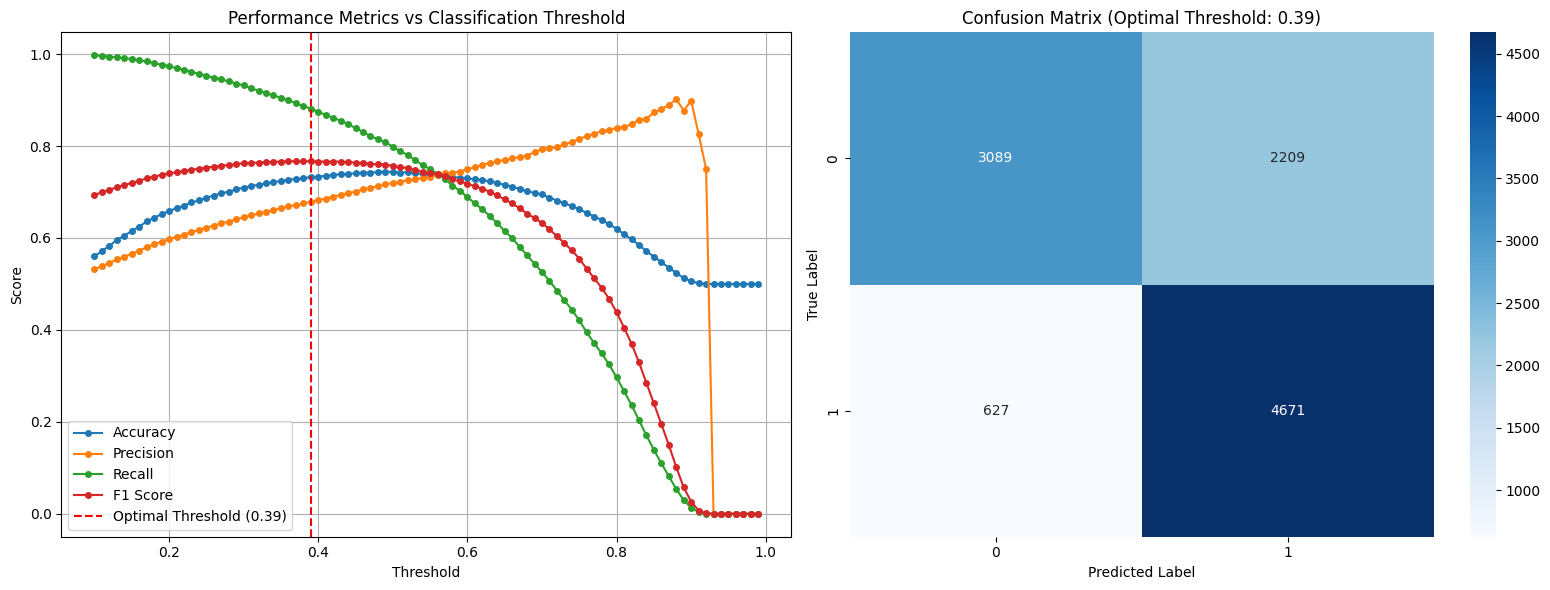

In [8]:
# ===== THRESHOLD ANALYSIS =====
print("\n=== THRESHOLD ANALYSIS ===")

# Get predictions with probabilities
y_pred_proba = model.predict(X_test).flatten()

# Test different thresholds
threshold_step = 0.01  # Configurable step for threshold exploration
thresholds = np.arange(0.1, 1.0, threshold_step)
results_thresholds = []

for output_threshold in thresholds:
    y_pred = (y_pred_proba > output_threshold).astype(int)
    
    precision = precision_score(Y_test, y_pred, zero_division=0)
    recall = recall_score(Y_test, y_pred, zero_division=0)
    f1 = f1_score(Y_test, y_pred, zero_division=0)
    accuracy = accuracy_score(Y_test, y_pred)
    
    results_thresholds.append({
        'threshold': output_threshold,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

# Find best threshold by F1 score
best_result = max(results_thresholds, key=lambda x: x['f1'])
optimal_threshold = best_result['threshold']

joblib.dump(optimal_threshold, threshold_path)

print(f"\n=== OPTIMAL THRESHOLD ===")
print(f"Best threshold (by F1): {optimal_threshold:.2f}")
print(f"Accuracy:  {best_result['accuracy']:.4f}")
print(f"Precision: {best_result['precision']:.4f}")
print(f"Recall:    {best_result['recall']:.4f}")
print(f"F1 Score:  {best_result['f1']:.4f}")

# Plot the metrics vs. threshold alongside the Confusion Matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

acc_list = [res['accuracy'] for res in results_thresholds]
prec_list = [res['precision'] for res in results_thresholds]
rec_list = [res['recall'] for res in results_thresholds]
f1_list = [res['f1'] for res in results_thresholds]
thresh_list = [res['threshold'] for res in results_thresholds]

ax1.plot(thresh_list, acc_list, label='Accuracy', marker='o', markersize=4)
ax1.plot(thresh_list, prec_list, label='Precision', marker='o', markersize=4)
ax1.plot(thresh_list, rec_list, label='Recall', marker='o', markersize=4)
ax1.plot(thresh_list, f1_list, label='F1 Score', marker='o', markersize=4)

# Highlight the optimal threshold
ax1.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')

ax1.set_title('Performance Metrics vs Classification Threshold')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.legend(loc='lower left')
ax1.grid(True)

# Confusion Matrix at Optimal Threshold (It's extremely useful for threshold analysis)
cm = confusion_matrix(Y_test, (y_pred_proba > optimal_threshold).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title(f'Confusion Matrix (Optimal Threshold: {optimal_threshold:.2f})')
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')

plt.tight_layout()
plt.show()